## Stage 12 — Multi-omics LASSO-Cox (mRNA + methylation)

**Goal:** survival prediction from PAM50 mRNA *and* promoter methylation. Tests whether adding methylation improves compared to the mRNA-only baseline (stage 11).

**Implementation:** same *Cox* + *LASSO* model with same engine (`CoxnetSurvivalAnalysis`) and nested 5-fold CV as in stage 11 

Only difference: the feature matrix grows, so the C-index is directly comparable to the baseline.

- methylation imputed *fold-safe* (KNN, fit on training only) and converted to *M-values* that are more robust
- expression + methylation standardized and concatenated into one feature vector

## Imports & setup

`sys.path.append("../scripts")` imports the KNN helper from scripts/ 


`fit_transform_train_test_methylation` from the KNN helper module --> fold-safe methylation imputation (same function as in the plotting stage 08).

In [32]:
import sys
sys.path.append("../scripts")  
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sksurv.util import Surv
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from KNN_Imputation_Helper_Function import fit_transform_train_test_methylation

warnings.simplefilter("ignore")
Path("../results/tables").mkdir(parents=True, exist_ok=True)


## Load and align data

`rna` expression (patients x genes), 

`meth` raw promoter methylation **with NaNs** (patients x CpGs), 

`surv` survival table, 

`folds` shared CV assignments.

- `set_index("patient")` patient ID as index for combining tables
- `surv["time"] > 0` keep only patients with valid, positive follow-up time
- `intersection` keep patients present in all four tables
- patient alignment with `loc`; `fold_id` outer CV fold per patient (same splits as in stage 11)

In [33]:
rna = pd.read_csv("../data/processed/rna_pam50.csv").set_index("patient")
meth = pd.read_csv("../data/processed/meth_pam50.csv").set_index("patient")
surv = pd.read_csv("../data/processed/survival_luminal_clean.csv").set_index("patient")
folds = pd.read_csv("../data/processed/cv_fold_assignments.csv").set_index("patient")
anno = pd.read_csv("../data/processed/cpg_gene_map.csv")

cpg_to_gene = dict(zip(anno["cpg"], anno["gene"]))
surv = surv[surv["time"].notna() & (surv["time"] > 0)]
patients = (rna.index.intersection(meth.index)
            .intersection(surv.index).intersection(folds.index))
rna, meth, surv = rna.loc[patients], meth.loc[patients], surv.loc[patients]
fold_id = folds.loc[patients, "fold"]
print(f"Patients: {len(patients)} | genes: {rna.shape[1]} | raw CpGs: {meth.shape[1]} "
      f"| folds: {sorted(fold_id.unique())}")


Patients: 556 | genes: 50 | raw CpGs: 572 | folds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## Helper function to construct survival target

`survival_y(ids)` pairs each patient's `event` (False = no observed death, True = dead) and `time` (days from diagnosis to death, or to last contact) into the survival target. Same as in 11.

In [34]:
def survival_y(ids):
    return Surv.from_arrays(event=surv.loc[ids, "event"].astype(bool).values,
                            time=surv.loc[ids, "time"].values)


## Beta --> M-value conversion

`beta_to_m(B)` converts methylation *beta* values (0–1) to *M-values*: `log2(beta / (1 - beta))`.

- beta is heteroscedastic (variance squeezed near 0 and 1); M-values are more *homoscedastic* --> better for linear models like Cox
- `B.clip(1e-4, 1 - 1e-4)` keeps beta away from exactly 0/1 so M stays finite (avoids log(0) / division by 0)

In [35]:
def beta_to_m(B):
    """Convert methylation beta values to M-values: M = log2(beta / (1 - beta)).
    Beta is clipped away from 0/1 to keep M finite."""
    B = B.clip(1e-4, 1 - 1e-4)
    return np.log2(B / (1 - B))


## Helper function to construct fold-safe features

Builds the combined feature matrix per fold  (fit on training only --> no *data leakage*).

- `fit_transform_train_test_methylation(...)` KNN-impute methylation, fit on train, apply to test
- `beta_to_m(...)` convert the imputed beta to M-values
- `StandardScaler` standardize methylation *and* expression, each fit on train only
- `pd.concat([Xr, Mm], axis=1)` concatenate expression + methylation into one feature vector per patient

In [36]:
def build_features(train_ids, test_ids):
    Bm_tr, Bm_te, _ = fit_transform_train_test_methylation(meth, train_ids, test_ids, scale=False)
    Mm_tr, Mm_te = beta_to_m(Bm_tr), beta_to_m(Bm_te)
    m_scaler = StandardScaler().fit(Mm_tr)
    Mm_tr = pd.DataFrame(m_scaler.transform(Mm_tr), index=Mm_tr.index, columns=Mm_tr.columns)
    Mm_te = pd.DataFrame(m_scaler.transform(Mm_te), index=Mm_te.index, columns=Mm_te.columns)

    r_scaler = StandardScaler().fit(rna.loc[train_ids])
    Xr_tr = pd.DataFrame(r_scaler.transform(rna.loc[train_ids]), index=train_ids, columns=rna.columns)
    Xr_te = pd.DataFrame(r_scaler.transform(rna.loc[test_ids]), index=test_ids, columns=rna.columns)
    X_tr = pd.concat([Xr_tr, Mm_tr], axis=1).to_numpy()
    X_te = pd.concat([Xr_te, Mm_te], axis=1).to_numpy()
    rna_names = [f"RNA: {g}" for g in rna.columns]
    meth_names = [f"METH: {cpg_to_gene.get(cpg, 'Unknown')} ({cpg})" 
                  for cpg in Mm_tr.columns]
    feature_names = rna_names + meth_names
    
    return X_tr, X_te, feature_names

## Function for alpha tuning

Identical to stage 11: nested inner 5-fold CV tunes the L1 strength `alpha`, separate from the outer test folds (no leakage during tuning).

- `L1_RATIO = 1.0` = pure *LASSO*.
- per inner fold: fit the whole L1 path, score each `alpha` by inner-validation C-index
- `try/except` skip alphas where Coxnet fails to converge
- return the `alpha` with the best mean inner C-index

In [ ]:
# selcting alpha using the 1 standard error rule
def select_alpha(X, y, alphas):
    inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = np.full((inner.get_n_splits(), len(alphas)), np.nan)

    for fold_idx, (i_tr, i_va) in enumerate(inner.split(X, y["event"])):
        model = CoxnetSurvivalAnalysis(
            l1_ratio=1.0,
            alphas=alphas,
            max_iter=100000
        )

        try:
            model.fit(X[i_tr], y[i_tr])

            for j, alpha in enumerate(alphas):
                risk = model.predict(X[i_va], alpha=alpha)
                scores[fold_idx, j] = concordance_index_censored(
                    y[i_va]["event"],
                    y[i_va]["time"],
                    risk
                )[0]

        except (ArithmeticError, ValueError) as e:
            print(f"Warning: inner fold {fold_idx} failed ({e})")
            continue

    mean_scores = np.nanmean(scores, axis=0)
    std_scores = np.nanstd(scores, axis=0, ddof=1)
    n_scores = np.sum(~np.isnan(scores), axis=0)
    se_scores = std_scores / np.sqrt(n_scores)

    best_idx = np.nanargmax(mean_scores)
    threshold = mean_scores[best_idx] - se_scores[best_idx]

    candidate_idx = np.where(mean_scores >= threshold)[0]

    chosen_idx = candidate_idx[0]

    return alphas[chosen_idx]


## Nested CV & result

Same nested scheme as in stage 11; only difference = the bigger feature matrix (genes + CpGs).

- outer loop over shared folds = honest evaluation on unseen patients
- `.alphas_` data-driven alpha path from the training fold, `select_alpha` picks the best
- `final` refit with best alpha, predict risk on the test fold, score by C-index
- `n_sel` / `features` how many features LASSO kept out of genes + CpGs
- `lasso_cox_multiomics_cv_results.csv` one row per fold


In [ ]:
# switch alpha if too small and fails to converge
def fit_final_model_with_fallback(X_tr, y_tr, selected_alpha, alphas):
    sorted_alphas = np.sort(alphas)

    candidate_alphas = sorted_alphas[sorted_alphas >= selected_alpha]

    for alpha in candidate_alphas:
        try:
            model = CoxnetSurvivalAnalysis(
                l1_ratio=1.0,
                alphas=[alpha],
                max_iter=100000
            )
            model.fit(X_tr, y_tr)
            return model, alpha
        except ArithmeticError:
            print(f"Alpha {alpha:.4g} failed; trying larger alpha...")

    raise RuntimeError("No alpha worked. Try increasing alpha_min_ratio.")

In [ ]:
rows = []
path_models = {}
feature_names_by_fold = {}

for f in sorted(fold_id.unique()):
    train_ids = fold_id.index[fold_id != f]
    test_ids = fold_id.index[fold_id == f]
    X_tr, X_te, feature_names = build_features(train_ids, test_ids)
    feature_names_by_fold[f] = feature_names
    y_tr, y_te = survival_y(train_ids), survival_y(test_ids)

    alphas = CoxnetSurvivalAnalysis(l1_ratio=1.0, n_alphas=100,
                                    alpha_min_ratio=0.05, max_iter=100000).fit(X_tr, y_tr).alphas_
    best_alpha = select_alpha(X_tr, y_tr, alphas)

    final, used_alpha = fit_final_model_with_fallback(X_tr, y_tr, best_alpha, alphas)
    
    path_model = CoxnetSurvivalAnalysis(l1_ratio=1.0, n_alphas=100, alpha_min_ratio=0.05, max_iter=100000)
    path_model.fit(X_tr, y_tr)
    path_models[f] = path_model

    train_risk = final.predict(X_tr)
    risk = final.predict(X_te)
    train_ci = concordance_index_censored(y_tr["event"], y_tr["time"], train_risk)[0]
    ci = concordance_index_censored(y_te["event"], y_te["time"], risk)[0]
    n_sel = int((final.coef_.ravel() != 0).sum())
    rows.append({"fold": f, "used alpha": used_alpha, "n_features_total": X_tr.shape[1],
                 "n_features_selected": n_sel, "train_c_index": train_ci, "test_c_index": ci, "n_test": len(test_ids)})
    print(f"Fold {f}: Train C-index={train_ci:.3f} | Test C-index={ci:.3f} | alpha={used_alpha:.4g} | "
          f"features={X_tr.shape[1]} | selected={n_sel}")

cv = pd.DataFrame(rows)
cv.to_csv("../results/tables/lasso_cox_multiomics_cv_results.csv", index=False)

best_fold = cv.loc[cv["test_c_index"].idxmax(), "fold"]
path_model = path_models[best_fold]

mean_ci, sd_ci = cv["test_c_index"].mean(), cv["test_c_index"].std()
print(f"\nMulti-omics LASSO-Cox C-index: {mean_ci:.3f} +/- {sd_ci:.3f} (5-fold CV)")


Fold 1: Train C-index=0.681 | Test C-index=0.432 | alpha=0.05795 | features=577 | selected=1
Fold 2: Train C-index=0.696 | Test C-index=0.535 | alpha=0.04267 | features=577 | selected=5
Fold 3: Train C-index=0.990 | Test C-index=0.605 | alpha=0.007628 | features=577 | selected=107
Fold 4: Train C-index=0.687 | Test C-index=0.701 | alpha=0.04483 | features=577 | selected=4
Alpha 0.00567 failed; trying larger alpha...
Fold 5: Train C-index=0.691 | Test C-index=0.649 | alpha=0.005844 | features=577 | selected=294

Multi-omics LASSO-Cox C-index: 0.585 +/- 0.105 (5-fold CV)


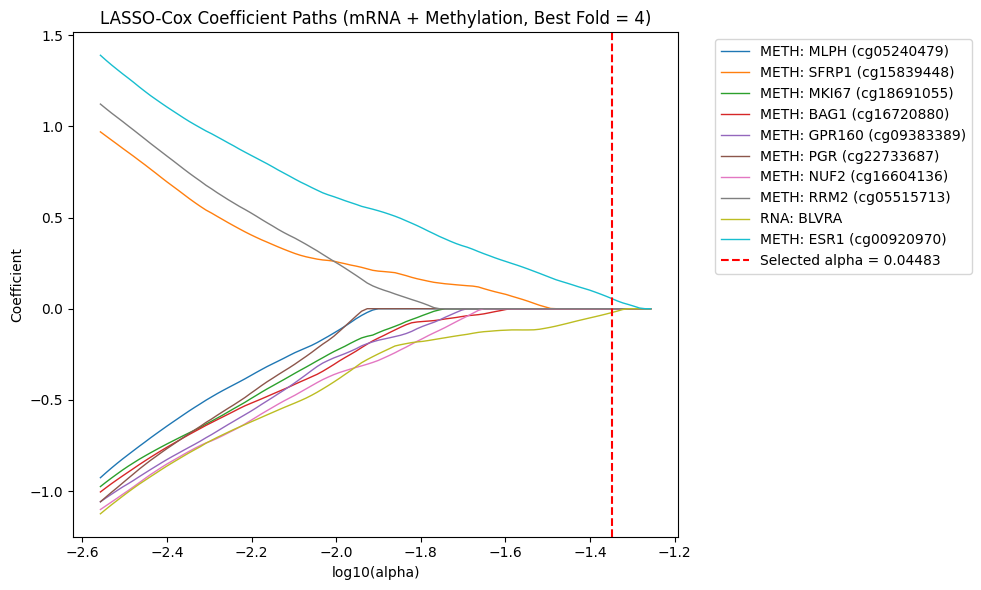

In [41]:
# Plotting the coefficient paths for the best fold
best_fold = cv.loc[cv["test_c_index"].idxmax(), "fold"]
path_model = path_models[best_fold]
feature_names = feature_names_by_fold[best_fold]

best_alpha_for_plot = cv.loc[cv["fold"] == best_fold, "used alpha"].iloc[0]

plt.figure(figsize=(10, 6))

importance = np.max(np.abs(path_model.coef_), axis=1)
top_features = np.argsort(importance)[-10:]

for i in top_features:
    plt.plot(np.log10(path_model.alphas_), path_model.coef_[i], linewidth=1, label=feature_names[i])

plt.axvline(np.log10(best_alpha_for_plot), color='red', linestyle='--', label=f"Selected alpha = {best_alpha_for_plot:.4g}")

plt.xlabel("log10(alpha)")
plt.ylabel("Coefficient")
plt.title(f"LASSO-Cox Coefficient Paths (mRNA + Methylation, Best Fold = {best_fold})")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../results/figures/lasso_cox_multiomics_coefficient_paths.png", dpi=300)
plt.show()